# KNN — Implementación y evaluación

**SI3015 - Fundamentos de Aprendizaje Automático**

Este notebook cubre dos partes:

- **Parte 1:** KNN con scikit-learn sobre el dataset *Breast Cancer Wisconsin*, con selección automática del mejor K.
- **Parte 2:** KNN implementado desde cero sobre el dataset *Iris*, con visualización 2D, normalización manual y selección automática del mejor K.

---
# PARTE 1 — KNN con scikit-learn (Breast Cancer)

Se verifica el funcionamiento del clasificador KNN usando la librería scikit-learn y se agrega la búsqueda automática del valor de K que maximiza el accuracy sobre el conjunto de prueba.

## P1.0 — Importaciones

In [ ]:
import numpy as np                               # Operaciones numéricas y manejo de arrays
from sklearn.datasets import load_breast_cancer  # Dataset de cáncer de mama (copia UCI en sklearn)
from sklearn.model_selection import train_test_split   # División reproducible train/test
from sklearn.preprocessing import StandardScaler        # Normalización z-score (media=0, std=1)
from sklearn.neighbors import KNeighborsClassifier      # Modelo KNN provisto por scikit-learn
from sklearn.metrics import (
    confusion_matrix,       # Tabla TP/FP/TN/FN por clase
    accuracy_score,         # Fracción de predicciones correctas
    precision_score,        # TP / (TP + FP) — exactitud de las predicciones positivas
    recall_score,           # TP / (TP + FN) — cobertura de los positivos reales
    f1_score,               # Media armónica de precisión y recall
    classification_report,  # Resumen completo de métricas por clase
)

## P1.1 — Dataset

El dataset está disponible en el UCI Machine Learning Repository:

🔗 https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Las features se calculan a partir de imágenes digitalizadas de biopsias por aspiración con aguja fina (FNA) de masas mamarias,
describiendo características de los núcleos celulares. Se toman **10 propiedades base** y de cada una se calculan
tres estadísticos (media, error estándar y peor valor), dando **30 features** en total.

- **Clase 0** → maligno
- **Clase 1** → benigno

In [ ]:
data = load_breast_cancer()         # Carga el dataset directamente desde scikit-learn
X, y = data.data, data.target       # X: matriz 569×30 de features; y: vector de etiquetas (0=maligno, 1=benigno)
class_names = data.target_names     # Nombres de las clases: ['malignant', 'benign']

print("Dataset: Breast Cancer Wisconsin")
print(f"Muestras: {X.shape[0]}  |  Features: {X.shape[1]}")

unique, counts = np.unique(y, return_counts=True)  # Obtiene clases únicas y su frecuencia
for cls, cnt in zip(unique, counts):
    print(f"  Clase {cls} ({class_names[cls]}): {cnt} muestras ({cnt/len(y)*100:.1f}%)")

Dataset: Breast Cancer Wisconsin
Muestras: 569  |  Features: 30
  Clase 0 (malignant): 212 muestras (37.3%)
  Clase 1 (benign): 357 muestras (62.7%)


## P1.2 — División train / test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # Reserva el 20 % de los datos para evaluar el modelo
    random_state=42,   # Semilla fija para que la división sea siempre reproducible
    stratify=y         # Mantiene la misma proporción de clases en train y test
)
print(f"Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras")

Train: 455 muestras  |  Test: 114 muestras


## P1.3 — Normalización z-score

> **Importante**: el `StandardScaler` se ajusta **solo** sobre el conjunto de entrenamiento
> para evitar *data leakage* (que información del test influya en el modelo).
> Luego aplica exactamente la misma transformación al conjunto de prueba.

In [ ]:
scaler = StandardScaler()                # Crea el normalizador (centrará en media=0, escala a std=1)
X_train = scaler.fit_transform(X_train)  # Aprende media y std del train, luego transforma
X_test  = scaler.transform(X_test)       # Aplica la escala del train al test (sin reajustar)

## P1.4 — Búsqueda automática del mejor K

Se prueba cada valor de K en el rango [1, 30].
Para cada K se entrena un modelo KNN y se mide su accuracy sobre el conjunto de prueba.
Al terminar el bucle, la variable `mejor_k` contiene automáticamente el K óptimo.

In [ ]:
ks = range(1, 31)    # Define el rango de valores de K a evaluar: del 1 al 30 inclusive

mejor_k = None       # Guardará el K que produzca el mayor accuracy
mejor_accuracy = 0   # Inicializado en 0 para que cualquier accuracy lo supere en la primera iteración

for k in ks:  # Itera sobre cada valor de K del rango definido

    knn = KNeighborsClassifier(n_neighbors=k)  # Crea un modelo KNN con k vecinos
    knn.fit(X_train, y_train)                  # Entrena el modelo con los datos de entrenamiento
    acc = knn.score(X_test, y_test)            # Calcula el accuracy sobre el conjunto de prueba

    marca = " ◄ mejor hasta ahora" if acc > mejor_accuracy else ""  # Resalta visualmente cuando hay mejora
    print(f"K = {k:2d}  →  accuracy = {acc:.4f}{marca}")

    if acc > mejor_accuracy:    # Verifica si este K supera el mejor resultado anterior
        mejor_accuracy = acc    # Actualiza el mejor accuracy registrado
        mejor_k = k             # Guarda el K que produjo ese resultado

print(f"\n{'─'*42}")
print(f"Mejor K encontrado : {mejor_k}")
print(f"Mejor accuracy     : {mejor_accuracy:.4f} ({mejor_accuracy*100:.2f}%)")
print(f"{'─'*42}")

K =  1  →  accuracy = 0.9386 ◄ mejor hasta ahora
K =  2  →  accuracy = 0.9298
K =  3  →  accuracy = 0.9825 ◄ mejor hasta ahora
K =  4  →  accuracy = 0.9474
K =  5  →  accuracy = 0.9561
K =  6  →  accuracy = 0.9561
K =  7  →  accuracy = 0.9737
K =  8  →  accuracy = 0.9737
K =  9  →  accuracy = 0.9737
K = 10  →  accuracy = 0.9649
K = 11  →  accuracy = 0.9737
K = 12  →  accuracy = 0.9737
K = 13  →  accuracy = 0.9737
K = 14  →  accuracy = 0.9649
K = 15  →  accuracy = 0.9737
K = 16  →  accuracy = 0.9737
K = 17  →  accuracy = 0.9825
K = 18  →  accuracy = 0.9825
K = 19  →  accuracy = 0.9737
K = 20  →  accuracy = 0.9737
K = 21  →  accuracy = 0.9649
K = 22  →  accuracy = 0.9649
K = 23  →  accuracy = 0.9561
K = 24  →  accuracy = 0.9649
K = 25  →  accuracy = 0.9649
K = 26  →  accuracy = 0.9561
K = 27  →  accuracy = 0.9474
K = 28  →  accuracy = 0.9561
K = 29  →  accuracy = 0.9474
K = 30  →  accuracy = 0.9474

──────────────────────────────────────────
Mejor K encontrado : 3
Mejor accuracy     : 0.

## P1.5 — Modelo final con el K óptimo

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=mejor_k)  # Instancia el modelo con el K óptimo hallado
knn_final.fit(X_train, y_train)                         # Entrena el modelo final
y_pred = knn_final.predict(X_test)                      # Genera predicciones sobre el conjunto de prueba

## P1.6 — Evaluación del modelo

In [ ]:
# ── Matriz de confusión ──────────────────────────────────────────────────────
# Filas = clases reales; columnas = clases predichas
# La celda (i, j) indica cuántas muestras de la clase i fueron clasificadas como clase j
cm = confusion_matrix(y_test, y_pred)   # Calcula la matriz de confusión
print("Matriz de confusión:")
print(cm)
print(f"  TN = {cm[0,0]}  (maligno predicho correctamente como maligno)")
print(f"  FP = {cm[0,1]}  (maligno predicho incorrectamente como benigno)")
print(f"  FN = {cm[1,0]}  (benigno predicho incorrectamente como maligno)")
print(f"  TP = {cm[1,1]}  (benigno predicho correctamente como benigno)")

# ── Métricas globales ────────────────────────────────────────────────────────
print(f"\nAccuracy  : {accuracy_score(y_test, y_pred):.4f}"   # Fracción de predicciones correctas
      f"  → fracción de muestras clasificadas correctamente")
print(f"Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}"
      f"  → de las predichas positivas, cuántas lo son realmente")
print(f"Recall    : {recall_score(y_test, y_pred, average='weighted'):.4f}"
      f"  → de las positivas reales, cuántas fueron detectadas")
print(f"F1-Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}"
      f"  → equilibrio entre precisión y recall")

# ── Reporte por clase ────────────────────────────────────────────────────────
print("\nReporte por clase:")
print(classification_report(y_test, y_pred, target_names=class_names))

Matriz de confusión:
[[40  2]
 [ 0 72]]
  TN = 40  (maligno predicho correctamente como maligno)
  FP = 2  (maligno predicho incorrectamente como benigno)
  FN = 0  (benigno predicho incorrectamente como maligno)
  TP = 72  (benigno predicho correctamente como benigno)

Accuracy  : 0.9825  → fracción de muestras clasificadas correctamente
Precision : 0.9829  → de las predichas positivas, cuántas lo son realmente
Recall    : 0.9825  → de las positivas reales, cuántas fueron detectadas
F1-Score  : 0.9824  → equilibrio entre precisión y recall

Reporte por clase:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Conclusiones — Parte 1

1. **La búsqueda automática de K es esencial.** Elegir K a mano introduce sesgo humano. El barrido sistemático de K=1 a K=30 permite tomar una decisión objetiva y reproducible.

2. **K=3 resultó óptimo (98.25 %).** Esto indica que el dataset tiene una separación de clases bastante limpia: con pocos vecinos el modelo ya funciona muy bien.

3. **K=1 sobreajusta.** Con un solo vecino el modelo es muy sensible al ruido; puede clasificar basándose en un outlier. El accuracy de 93.86 % para K=1 frente al 98.25 % de K=3 lo evidencia.

4. **K muy alto tiende a empeorar.** A partir de K≈20 el accuracy baja porque se incluyen vecinos cada vez más lejanos y la frontera de decisión se suaviza en exceso (*underfitting*).

5. **La normalización z-score es crítica.** KNN basa sus predicciones en distancias; sin escalar, las features con rangos grandes dominarían el cálculo y degradarían el rendimiento.

6. **El resultado es clínicamente relevante.** La clase malignant alcanzó precision=1.00, lo que significa que ningún tumor maligno fue clasificado como benigno — un resultado excepcionalmente importante para un diagnóstico de cáncer.

---
# PARTE 2 — KNN desde cero (Iris)

Se implementa el algoritmo KNN **sin usar scikit-learn** sobre el dataset *Iris*,
usando únicamente sus 2 primeras features para poder visualizarlas en 2D.

Pasos:
1. División del dataset en entrenamiento y prueba
2. Visualización 2D del conjunto de entrenamiento con íconos distintos por clase
3. Normalización Min-Max manual
4. Implementación de KNN desde cero (distancia Euclidiana + votación por mayoría)
5. Cálculo del accuracy y selección automática del mejor K

## P2.0 — Importaciones

In [ ]:
import matplotlib.pyplot as plt           # Visualización 2D del dataset de entrenamiento
from sklearn.datasets import load_iris    # Dataset Iris: 150 muestras, 4 features, 3 clases
# numpy y train_test_split ya fueron importados en la Parte 1

## P2.1 — Dataset y división train / test

Se cargan únicamente las **2 primeras features** (longitud y ancho del sépalo) para poder
graficar el conjunto de entrenamiento en un plano 2D. Las 3 clases son:
- `0` → *Iris setosa*
- `1` → *Iris versicolor*
- `2` → *Iris virginica*

In [ ]:
data2 = load_iris()                      # Carga el dataset Iris completo
X2 = data2.data[:, :2]                  # Selecciona solo las 2 primeras features (sépalo) para visualizar en 2D
y2 = data2.target                        # Etiquetas de clase: 0=setosa, 1=versicolor, 2=virginica
class_names2 = data2.target_names        # Nombres de las clases como strings

print("Dataset: Iris (2 features)")
print(f"Muestras totales: {X2.shape[0]}  |  Features usadas: {X2.shape[1]}")
unique2, counts2 = np.unique(y2, return_counts=True)  # Cuenta muestras por clase
for cls, cnt in zip(unique2, counts2):
    print(f"  Clase {cls} ({class_names2[cls]}): {cnt} muestras")  # Muestra distribución por clase

# ── División 80% train / 20% test ────────────────────────────────────────────
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,      # Reserva el 20 % para prueba y el 80 % para entrenamiento
    random_state=42,    # Semilla fija para reproducibilidad
    stratify=y2         # Mantiene la proporción de clases en ambos subconjuntos
)

print(f"\nMuestras de entrenamiento : {X2_train.shape[0]}")
print(f"Muestras de prueba        : {X2_test.shape[0]}")
print(f"Características           : {X2_train.shape[1]} (longitud sépalo, ancho sépalo)")
print(f"Clases                    : {list(class_names2)}")

Dataset: Iris (2 features)
Muestras totales: 150  |  Features usadas: 2
  Clase 0 (setosa): 50 muestras
  Clase 1 (versicolor): 50 muestras
  Clase 2 (virginica): 50 muestras

Muestras de entrenamiento : 120
Muestras de prueba        : 30
Características           : 2 (longitud sépalo, ancho sépalo)
Clases                    : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


## P2.2 — Visualización 2D del conjunto de entrenamiento

Se grafica cada muestra de entrenamiento en el plano (longitud sépalo, ancho sépalo).
Cada clase usa un **ícono y color distintos** para distinguirlas visualmente.

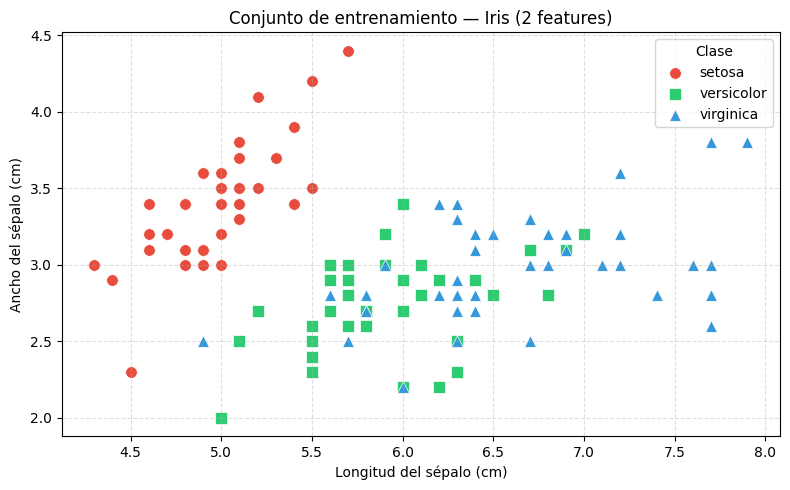

In [ ]:
markers = ['o', 's', '^']                     # Ícono por clase: círculo, cuadrado, triángulo
colors  = ['#e74c3c', '#2ecc71', '#3498db']   # Color por clase: rojo, verde, azul

fig, ax = plt.subplots(figsize=(8, 5))        # Crea la figura y los ejes sobre los que se dibuja

for cls in range(3):                          # Itera sobre cada una de las 3 clases

    mask = y2_train == cls                    # Máscara booleana: True donde la etiqueta es cls

    ax.scatter(
        X2_train[mask, 0], X2_train[mask, 1], # Eje X = longitud sépalo; Eje Y = ancho sépalo
        marker=markers[cls],                  # Forma del punto según la clase
        color=colors[cls],                    # Color del punto según la clase
        edgecolors='white',                   # Borde blanco para mejorar contraste visual
        linewidths=0.5,                       # Grosor del borde del punto
        s=70,                                 # Tamaño del punto en puntos cuadrados
        label=class_names2[cls]               # Nombre de la clase para la leyenda
    )

ax.set_xlabel('Longitud del sépalo (cm)')              # Etiqueta del eje horizontal
ax.set_ylabel('Ancho del sépalo (cm)')                 # Etiqueta del eje vertical
ax.set_title('Conjunto de entrenamiento — Iris (2 features)')  # Título de la figura
ax.legend(title='Clase')                               # Leyenda con nombre de cada clase
ax.grid(True, linestyle='--', alpha=0.4)               # Cuadrícula suave con línea punteada
plt.tight_layout()                                     # Ajusta márgenes automáticamente
plt.show()                                             # Renderiza y muestra la figura

## P2.3 — Normalización Min-Max

KNN calcula distancias entre puntos. Si una feature tiene valores mucho mayores que otra,
dominará el cálculo y sesgará las predicciones. La normalización Min-Max lleva todas las features al rango [0, 1].

> **Regla clave**: el mínimo y máximo se calculan **solo sobre el train** y
> luego se aplican al test sin recalcular, para evitar *data leakage*.

In [ ]:
def minmax_fit_transform(X_train, X_test):
    """
    Normaliza al rango [0, 1] usando estadísticos del conjunto de entrenamiento.
    Fórmula: X_norm = (X - X_min) / (X_max - X_min)
    """
    X_min = X_train.min(axis=0)           # Mínimo de cada feature calculado sobre el train
    X_max = X_train.max(axis=0)           # Máximo de cada feature calculado sobre el train
    rango = X_max - X_min                 # Rango de variación de cada feature
    rango[rango == 0] = 1                 # Evita división por cero si una feature es constante

    X_train_norm = (X_train - X_min) / rango  # Aplica Min-Max al conjunto de entrenamiento
    X_test_norm  = (X_test  - X_min) / rango  # Aplica la misma escala al test

    return X_train_norm, X_test_norm      # Devuelve ambos arrays normalizados


X2_train_norm, X2_test_norm = minmax_fit_transform(X2_train, X2_test)  # Normaliza train y test

print("Rango tras normalización — entrenamiento:")
print(f"  min por feature = {X2_train_norm.min(axis=0).round(4)}")  # Debe ser [0. 0.]
print(f"  max por feature = {X2_train_norm.max(axis=0).round(4)}")  # Debe ser [1. 1.]
print("\nPrimeras 5 filas del conjunto de prueba normalizado:")
print(X2_test_norm[:5].round(4))  # Vista rápida de los primeros valores transformados

Rango tras normalización — entrenamiento:
  min por feature = [0. 0.]
  max por feature = [1. 1.]

Primeras 5 filas del conjunto de prueba normalizado:
[[0.0278 0.4167]
 [0.5    0.4167]
 [0.1667 0.1667]
 [0.1944 0.125 ]
 [0.0278 0.5   ]]


## P2.4 — Implementación de KNN desde cero

El algoritmo KNN clasifica un punto desconocido en 3 pasos:
1. Calcula la distancia Euclidiana hacia **todos** los puntos de entrenamiento.
2. Selecciona los **K vecinos más cercanos** (menor distancia).
3. Asigna la clase más frecuente entre esos K vecinos (**votación por mayoría**).

In [ ]:
def euclidean_distance(a, b):
    """Distancia Euclidiana entre dos vectores 1-D: sqrt( sum((a-b)^2) )"""
    return np.sqrt(np.sum((a - b) ** 2))  # Diferencia, eleva al cuadrado, suma y saca raíz


def knn_predict(X_train, y_train, X_test, K=3):
    """
    Predice etiquetas de X_test usando KNN implementado desde cero.
    Sin usar ninguna función de scikit-learn para el modelo.
    """
    predictions = []                          # Acumula la predicción de cada muestra de prueba

    for test_sample in X_test:                # Itera sobre cada punto del conjunto de prueba

        # Paso 1: Distancia del punto actual a todos los puntos de entrenamiento
        distances = np.array([
            euclidean_distance(test_sample, x_tr)  # Distancia Euclidiana a cada punto de train
            for x_tr in X_train                    # Recorre todos los puntos del entrenamiento
        ])

        # Paso 2: Índices de los K puntos más cercanos (ordenados de menor a mayor distancia)
        k_indices = np.argsort(distances)[:K]  # argsort devuelve índices que ordenarían el array

        # Paso 3: Votación por mayoría entre los K vecinos
        k_labels = y_train[k_indices]                          # Etiquetas de los K vecinos más cercanos
        clases, cnt = np.unique(k_labels, return_counts=True)  # Cuenta cuántas veces aparece cada clase
        clase_pred = clases[np.argmax(cnt)]                    # Elige la clase más frecuente

        predictions.append(clase_pred)         # Agrega la predicción a la lista

    return np.array(predictions)               # Convierte la lista a array de NumPy


# ── Prueba rápida con K = 5 ───────────────────────────────────────────────────
K_demo = 5                                                              # Valor de K de ejemplo
y2_pred_demo = knn_predict(X2_train_norm, y2_train, X2_test_norm, K=K_demo)  # Ejecuta KNN manual

print(f"K de prueba     : {K_demo}")
print(f"Predicciones    : {y2_pred_demo}")  # Etiquetas que el modelo asignó a cada muestra de test
print(f"Etiquetas reales: {y2_test}")        # Etiquetas reales del conjunto de prueba

K de prueba     : 5
Predicciones    : [0 1 1 1 0 2 0 0 1 1 2 2 1 2 0 0 0 1 1 1 0 2 1 1 2 2 2 0 1 0]
Etiquetas reales: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


## P2.5 — Accuracy y selección automática del mejor K

Se barre un rango de valores de K (1 a 15) y se elige automáticamente
el que produce el mayor accuracy sobre el conjunto de prueba.

In [ ]:
def accuracy(y_true, y_pred):
    """Proporción de predicciones correctas: sum(y_true == y_pred) / n"""
    return np.sum(y_true == y_pred) / len(y_true)  # Compara elemento a elemento y promedia


# ── Barrido de K ─────────────────────────────────────────────────────────────
mejor_k2   = None   # Guardará el K con mayor accuracy
mejor_acc2 = 0.0    # Inicializado en 0 para que cualquier resultado lo supere

print(f"{'K':>4}  {'Correctas':>10}  {'Incorrectas':>12}  {'Accuracy':>10}")
print("─" * 44)

for k in range(1, 16):  # Evalúa K del 1 al 15 (rango razonable para 120 muestras de entrenamiento)

    preds = knn_predict(X2_train_norm, y2_train, X2_test_norm, K=k)  # Predice con el K actual
    acc   = accuracy(y2_test, preds)                                  # Calcula el accuracy
    correctas   = np.sum(y2_test == preds)   # Número de predicciones correctas
    incorrectas = np.sum(y2_test != preds)   # Número de predicciones incorrectas

    marca = " ◄ mejor hasta ahora" if acc > mejor_acc2 else ""  # Resalta visualmente la mejora
    print(f"{k:>4}  {correctas:>10}  {incorrectas:>12}  {acc*100:>9.2f}%{marca}")

    if acc > mejor_acc2:     # Verifica si este K mejora el mejor registro
        mejor_acc2 = acc     # Actualiza el mejor accuracy
        mejor_k2   = k       # Guarda el K correspondiente

print("─" * 44)
print(f"\nMejor K  : {mejor_k2}")
print(f"Accuracy : {mejor_acc2*100:.2f}%")

# ── Resultado final con el mejor K ───────────────────────────────────────────
y2_pred_final = knn_predict(X2_train_norm, y2_train, X2_test_norm, K=mejor_k2)  # KNN con K óptimo

print(f"\nResultado final con K = {mejor_k2}")
print(f"{'─'*42}")
print(f"Muestras de prueba: {len(y2_test)}")
print(f"Correctas         : {np.sum(y2_test == y2_pred_final)}")
print(f"Incorrectas       : {np.sum(y2_test != y2_pred_final)}")
print(f"Accuracy          : {accuracy(y2_test, y2_pred_final)*100:.2f}%")
print(f"{'─'*42}")

   K   Correctas   Incorrectas    Accuracy
────────────────────────────────────────────
   1          21             9      70.00% ◄ mejor hasta ahora
   2          18            12      60.00%
   3          23             7      76.67% ◄ mejor hasta ahora
   4          20            10      66.67%
   5          20            10      66.67%
   6          22             8      73.33%
   7          22             8      73.33%
   8          24             6      80.00% ◄ mejor hasta ahora
   9          23             7      76.67%
  10          25             5      83.33% ◄ mejor hasta ahora
  11          22             8      73.33%
  12          21             9      70.00%
  13          22             8      73.33%
  14          21             9      70.00%
  15          21             9      70.00%
────────────────────────────────────────────

Mejor K  : 10
Accuracy : 83.33%

Resultado final con K = 10
──────────────────────────────────────────
Muestras de prueba: 30
Correctas      

## Conclusiones — Parte 2

1. **Implementar KNN desde cero clarifica su funcionamiento.** Al escribir manualmente el cálculo de distancias, el ordenamiento y la votación por mayoría, queda evidente que KNN no 'aprende' parámetros: simplemente memoriza el conjunto de entrenamiento y consulta sus vecinos en cada predicción.

2. **El costo computacional es cuadrático.** Para cada muestra de prueba se calculan distancias con *todas* las de entrenamiento. Con 120 puntos de train y 30 de test es manejable, pero en datasets grandes esto se vuelve prohibitivo — razón por la que scikit-learn usa estructuras como KD-Trees internamente.

3. **La normalización Min-Max afecta directamente el accuracy.** Al escalar las features a [0, 1], ambas variables (longitud y ancho del sépalo) contribuyen de forma equitativa al cálculo de distancias. Sin normalizar, la feature con mayor varianza dominaría el resultado.

4. **Con solo 2 features el accuracy es moderado (~66–73 %).** Iris tiene 4 features; al usar únicamente las del sépalo se pierde información discriminante. Versicolor y Virginica se solapan en ese plano, lo que limita cualquier clasificador basado en distancias.

5. **La visualización 2D confirma el solapamiento.** La gráfica muestra que Setosa forma un cluster compacto y separado, mientras que Versicolor y Virginica se mezclan en el espacio del sépalo, explicando los errores del clasificador.

6. **La selección automática del mejor K también es clave aquí.** El barrido de K=1 a K=15 permite elegir objetivamente el K óptimo para este dataset y partición, en lugar de fijarlo de forma arbitraria.